## TidyTuesday 2026 week 34: Country lyrics

Plotting mentions of 'girl' in Billboard Top 30 Country songs 2013-2019

Source: [TidyTuesday](https://github.com/rfordatascience/tidytuesday)

In [2]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt


import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from matplotlib import font_manager
#font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

## Prepare data

In [ ]:
#load data
df = pd.read_csv("country_lyrics.csv")

# make a list of words from the raw lyrics
def words_from_lyrics(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)   # keep only letters and spaces
    return text.split()

df["word_list"] = df["lyrics"].apply(words_from_lyrics)

#add ID column
df["ID"] = [i + 1 for i in df.reset_index()["index"]]

#Add total song length
df["song_length"] = [len(i) for i in df["word_list"]]

#add common nouns (as identified via spaCy)
words_to_search = ['girl', 'baby', 'night', 'love', 'heart', 'song', 'tonight', 'town', 'road', 'home']

### Add counts of common words
for word in words_to_search:
    df[f"count_{word}"] = df['word_list'].apply(lambda x: x.count(word))

### get positions of common words
pos = []

for row_idx, row in df.iterrows():
    tokens = row["word_list"] if isinstance(row["word_list"], list) else []
    
    for word in words_to_search:
        positions = [i for i, token in enumerate(tokens) if token == word]
        if positions:
            pos.append({
                "ID": row["ID"],  
                "word": word,
                "positions": positions
            })

pos_df = pd.DataFrame(pos)
pos_df_pivot = pos_df.pivot(index="ID", columns="word", values="positions").reset_index()
df = pd.merge(df, pos_df_pivot, left_on="ID", right_on="ID", how="left", suffixes=("", "_pos") )

In [5]:
def create_spiral_equal_arc(df, col_name='count', turns=7, start_radius=0.1):
    """
    Create a spiral with equal arc spacing and an offset starting radius.
    
    Parameters:
    - df: DataFrame containing the data.
    - col_name: Column name for the values to plot.
    - turns: Number of turns in the spiral.
    - start_radius: The starting radius of the spiral.
    
    Returns:
    - theta: Angular positions of the points.
    - r: Radial positions of the points.
    - values: Values corresponding to the points.
    """
    n = len(df)
    values = df[col_name].values.astype(float)

    # Archimedean spiral sampling for even spacing
    a = start_radius  # Start radius
    b = 0.015  # Growth rate of the spiral

    theta_dense = np.linspace(0, 2 * np.pi * turns, 20000)
    r_dense = a + b * theta_dense  # Offset starting radius

    dtheta = np.diff(theta_dense)
    drdtheta = np.full_like(r_dense[:-1], b)
    ds = np.sqrt(r_dense[:-1]**2 + drdtheta**2) * dtheta

    s = np.concatenate(([0], np.cumsum(ds)))
    s_target = np.linspace(0, s[-1], n)

    theta = np.interp(s_target, s, theta_dense)
    r = np.interp(s_target, s, r_dense)

    return theta, r, values

In [6]:
max_song_length = 503
word = "girl"

# Convert missing values to empty lists
df[word] = df[word].apply(lambda x: x if isinstance(x, list) else [])

# Build position frequency across all songs
counts_per_pos = {"pos": [], "count": []}

for i in range(max_song_length):
    counter = sum(1 for positions in df[word] if i in positions)
    counts_per_pos["pos"].append(i)
    counts_per_pos["count"].append(counter)

counts_df = pd.DataFrame(counts_per_pos)
counts_df["opacity"] = counts_df["opacity"] = [
    1.0 if i  >0 
    else 0.7
    for i in counts_df["count"]
]

max(counts_df["count"])

11

## Data vis

In [169]:
#COLORS
clrs = {"title" : "#451A14", "bg":"#C3CDD2", "annotation": "#3E595B"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#7f895a'), 
(p,  '#65764f'),
(0.4,  '#4d6244'),
(0.6,  '#384f39'),
(0.8, '#263c2d'),
(1.0,'#172a21'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')
from pyfonts import load_google_font
body_font_r = load_google_font("Noto Serif", weight="regular", italic=False)
body_font_sb = load_google_font("Noto Serif", weight="semi-bold", italic=False)
body_font_l = load_google_font("Noto Serif", weight="light", italic=False)

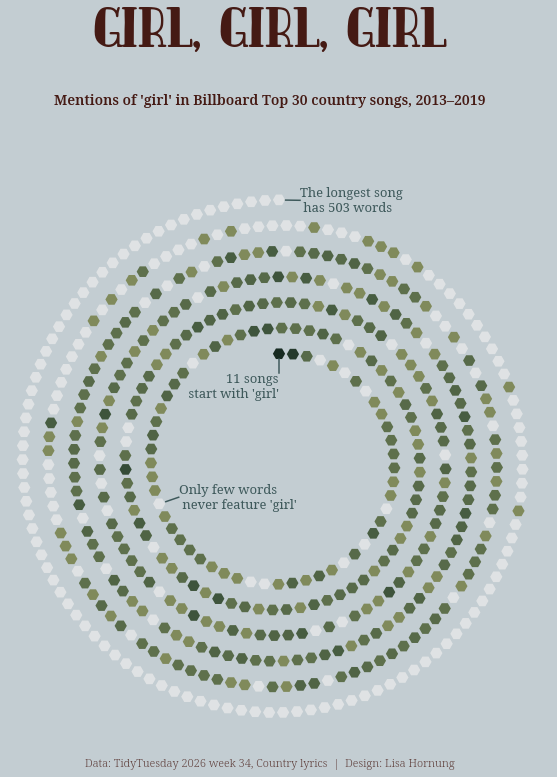

In [168]:
#get positions for dots
theta, r, values = create_spiral_equal_arc(counts_df,
                                            col_name='count', 
                                            turns=6,
                                            start_radius=0.4)

# Create figure
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10,10))
fig.set_facecolor(clrs["bg"])
ax.axis('off')

#plot dots along spiral
scatter = ax.scatter(
        theta,
        r,
        c=values,
        cmap=cmap,
        vmin=0,
        vmax=11,
        s=150,
        alpha=counts_df["opacity"],
       linewidth=0,
       marker='H'
    )
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

## Annotation
ax.plot([0,0], [0.33, 0.38],color=clrs["annotation"])
ax.text(0, 0.33, "11 songs\n start with 'girl'", ha="right", va="top",
        fontsize=13, font=body_font_r,color=clrs["annotation"], fontweight="bold")

ax.plot([0.025,0.08], [0.965, 0.967], color=clrs["annotation"])
ax.text(0.08, 0.967, "The longest song\n has 503 words", color=clrs["annotation"],
        ha="left", va="center", fontsize=13, font=body_font_r, fontweight="bold")


ax.plot([4.38,4.38], [0.39, 0.44],color=clrs["annotation"])
ax.text(4.38, 0.39, "Only few words\n never feature 'girl'", color=clrs["annotation"],
        ha="left", va="center", fontsize=13, font=body_font_r, fontweight="bold")

#add title
fig.text(0.5,1.08, "girl, girl, girl", color=clrs["title"], fontsize=50, fontproperties=title_font, ha="center")
fig.text(0.5,1, "Mentions of 'girl' in Billboard Top 30 country songs, 2013–2019", color=clrs["title"], 
         fontsize=14,ha="center", font=body_font_sb)
fig.text(0.5,0.08, "Data: TidyTuesday 2026 week 34, Country lyrics  |  Design: Lisa Hornung", color=clrs["title"], 
         fontsize=11, font=body_font_l, ha="center", alpha=0.8)

#export
plt.savefig("girl-mentions.png", pad_inches=1, bbox_inches='tight')

plt.show()

## Playground

In [ ]:
#COLORS
clrs = {"title" : "#001920", "bg":"#C1D1D7"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#e58c75'), 
(p,  '#c96a54'),
(0.4,  '#ac4835'),
(0.6,  '#8a3122'),
(0.8, '#67251b'),
(1.0,'#451a14'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

In [ ]:
#COLORS
clrs = {"title" : "#001920", "bg":"#C3CDD2"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#7f895a'), 
(p,  '#65764f'),
(0.4,  '#4d6244'),
(0.6,  '#384f39'),
(0.8, '#263c2d'),
(1.0,'#172a21'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

In [ ]:
#COLORS
clrs = {"title" : "#cccccc", "bg":"#0E0821"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#ff00ff'), 
(p,  '#ff33cc'),
(0.4,  '#ff6699'),
(0.6,  '#ff9966'),
(0.8, '#ffcc33'),
(1.0,'#ffff00'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

In [120]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Get the 'cool' colormap
cmap = plt.cm.spring

# Sample a few evenly spaced colors
num_colors = 6  #
sampled_colors = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Convert to hex codes
hex_codes = [mcolors.rgb2hex(color[:3]) for color in sampled_colors]

print(hex_codes)

['#ff00ff', '#ff33cc', '#ff6699', '#ff9966', '#ffcc33', '#ffff00']


In [105]:
#COLOR SCALE
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#015883'), 
(p,  '#04739e'),
(0.4,  '#1190b8'),
(0.6,  '#24aed0'),
(0.8, '#3bcce7'),
(1.0,'#56ebfc'),
])

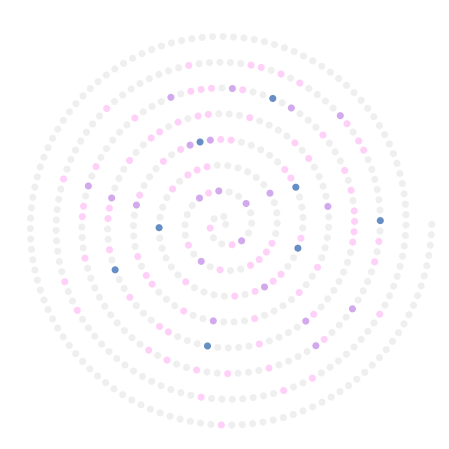

In [48]:
def create_spiral_equal_arc(df, col_name='count', turns=8, cmap=cmap):
    n = len(df)
    values = df[col_name].values.astype(float)

    # Archimedean spiral sampling for even spacing
    a = 0.01
    b = 0.04

    theta_dense = np.linspace(0, 2 * np.pi * turns, 20000)
    r_dense = a + b * theta_dense

    dtheta = np.diff(theta_dense)
    drdtheta = np.full_like(r_dense[:-1], b)
    ds = np.sqrt(r_dense[:-1]**2 + drdtheta**2) * dtheta

    s = np.concatenate(([0], np.cumsum(ds)))
    s_target = np.linspace(0, s[-1], n)

    theta = np.interp(s_target, s, theta_dense)
    r = np.interp(s_target, s, r_dense)

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,8))
    scatter = ax.scatter(
        theta,
        r,
        c=values,
        cmap=cmap,
        s=50,
        alpha=df["opacity"],
       linewidth=0
    )
    ax.axis('off')
    plt.show()

create_spiral_equal_arc(counts_df, col_name='count', turns=8)

## Exploration

### Identify most common nouns using SpaCy

In [115]:
import spacy

nlp = spacy.load("en_core_web_sm")

def get_noun_tokens(text):
    doc = nlp(str(text))
    nouns = []
    for token in doc:
        if token.pos_ in {"NOUN", "PROPN"} and not token.is_stop and token.is_alpha:
            nouns.append(token.lemma_.lower())
    return nouns

df["noun_tokens"] = df["lyrics"].apply(get_noun_tokens)

noun_counts = (
    df
    .explode("noun_tokens")
    .dropna(subset=["noun_tokens"])
    .groupby("noun_tokens", as_index=False)
    .size()
    .rename(columns={"noun_tokens": "word", "size": "mentions"})
    .sort_values("mentions", ascending=False)
    .reset_index(drop=True)
)

noun_counts.head(20)

,word,mentions
0,girl,876
1,baby,760
2,time,561
3,night,515
4,way,418
5,love,392
6,heart,337
7,tonight,333
8,thing,285
9,song,280
